# Análisis de Sentimientos en X (antes Twitter) y Facebook


In [ ]:
# Para instalar VADER y el traductor de Google (en caso de ser necesario)
# pip install vaderSentiment
# pip install deep-translator

## Análisis de tweets del conflicto Ucrania - Rusia

In [ ]:
import pandas as pd # Para manejar los datos del csv
import re # Sirve para buscar y reemplazar los patrones de texto
import matplotlib.pyplot as plt # Graficación
import seaborn as sns
from collections import Counter
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer # Importar VADER
import time

In [ ]:
# Preprocesamiento de los datos

# Cargamos el csv con los twetts
df = pd.read_csv('ukraine_tweets.csv')

# Usamos la columna 'language' para solo usar los tweets en ingles
df_ingles = df[df['language'] == 'en'].copy()

# Limpiamos los twetts para obtener solo la información necesaria
def limpieza_datos(texto):
    if not isinstance(texto, str):
        return ""
    # Eliminamos URL´s
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)
    # Eliminamos las menciones a otros @usuarios
    texto = re.sub(r'@\w+', '', texto)
    # Eliminamos hashtags
    texto = re.sub(r'#\w+', '', texto)
    # Mantenemos solo palabras y puntuación enfática para mejorar el análisis de VADER
    texto = re.sub(r'[^\w\s!?.,:;()\'-]', ' ', texto)
    # Eliminar espacios múltiples
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Aquí obtenemos los datos filtrados
df_ingles['filtrado_text'] = df_ingles['text'].apply(limpieza_datos)

In [ ]:
# Análisis de VADER

# Cargamos el análizador de VADER
analyzer = SentimentIntensityAnalyzer()

# Análizamos un tweet y devuelve un cierto nivel de sentimiento
def analizar_sentimiento(texto):
    # Devuelve un cierto valor para cada palabra del tweet
    scores = analyzer.polarity_scores(str(texto))

    # De los valores obtenidos anteriormente extraemos un compound (valor del tweet en general)
    compound = scores['compound']

    # Clasificación de VADER
    if compound >= 0.05:
        return 'POSITIVO', compound
    elif compound <= -0.05:
        return 'NEGATIVO', compound
    else:
        return 'NEUTRO', compound

# Aplicamos a todo el dataframe y hacemos que pandas separe los datos obtenidos en dos columnas las cuales tendrán "Sentimiento, Compound"
resultados = df_ingles['filtrado_text'].apply(lambda x: pd.Series(analizar_sentimiento(x)))
df_ingles[['sentimiento', 'compound']] = resultados

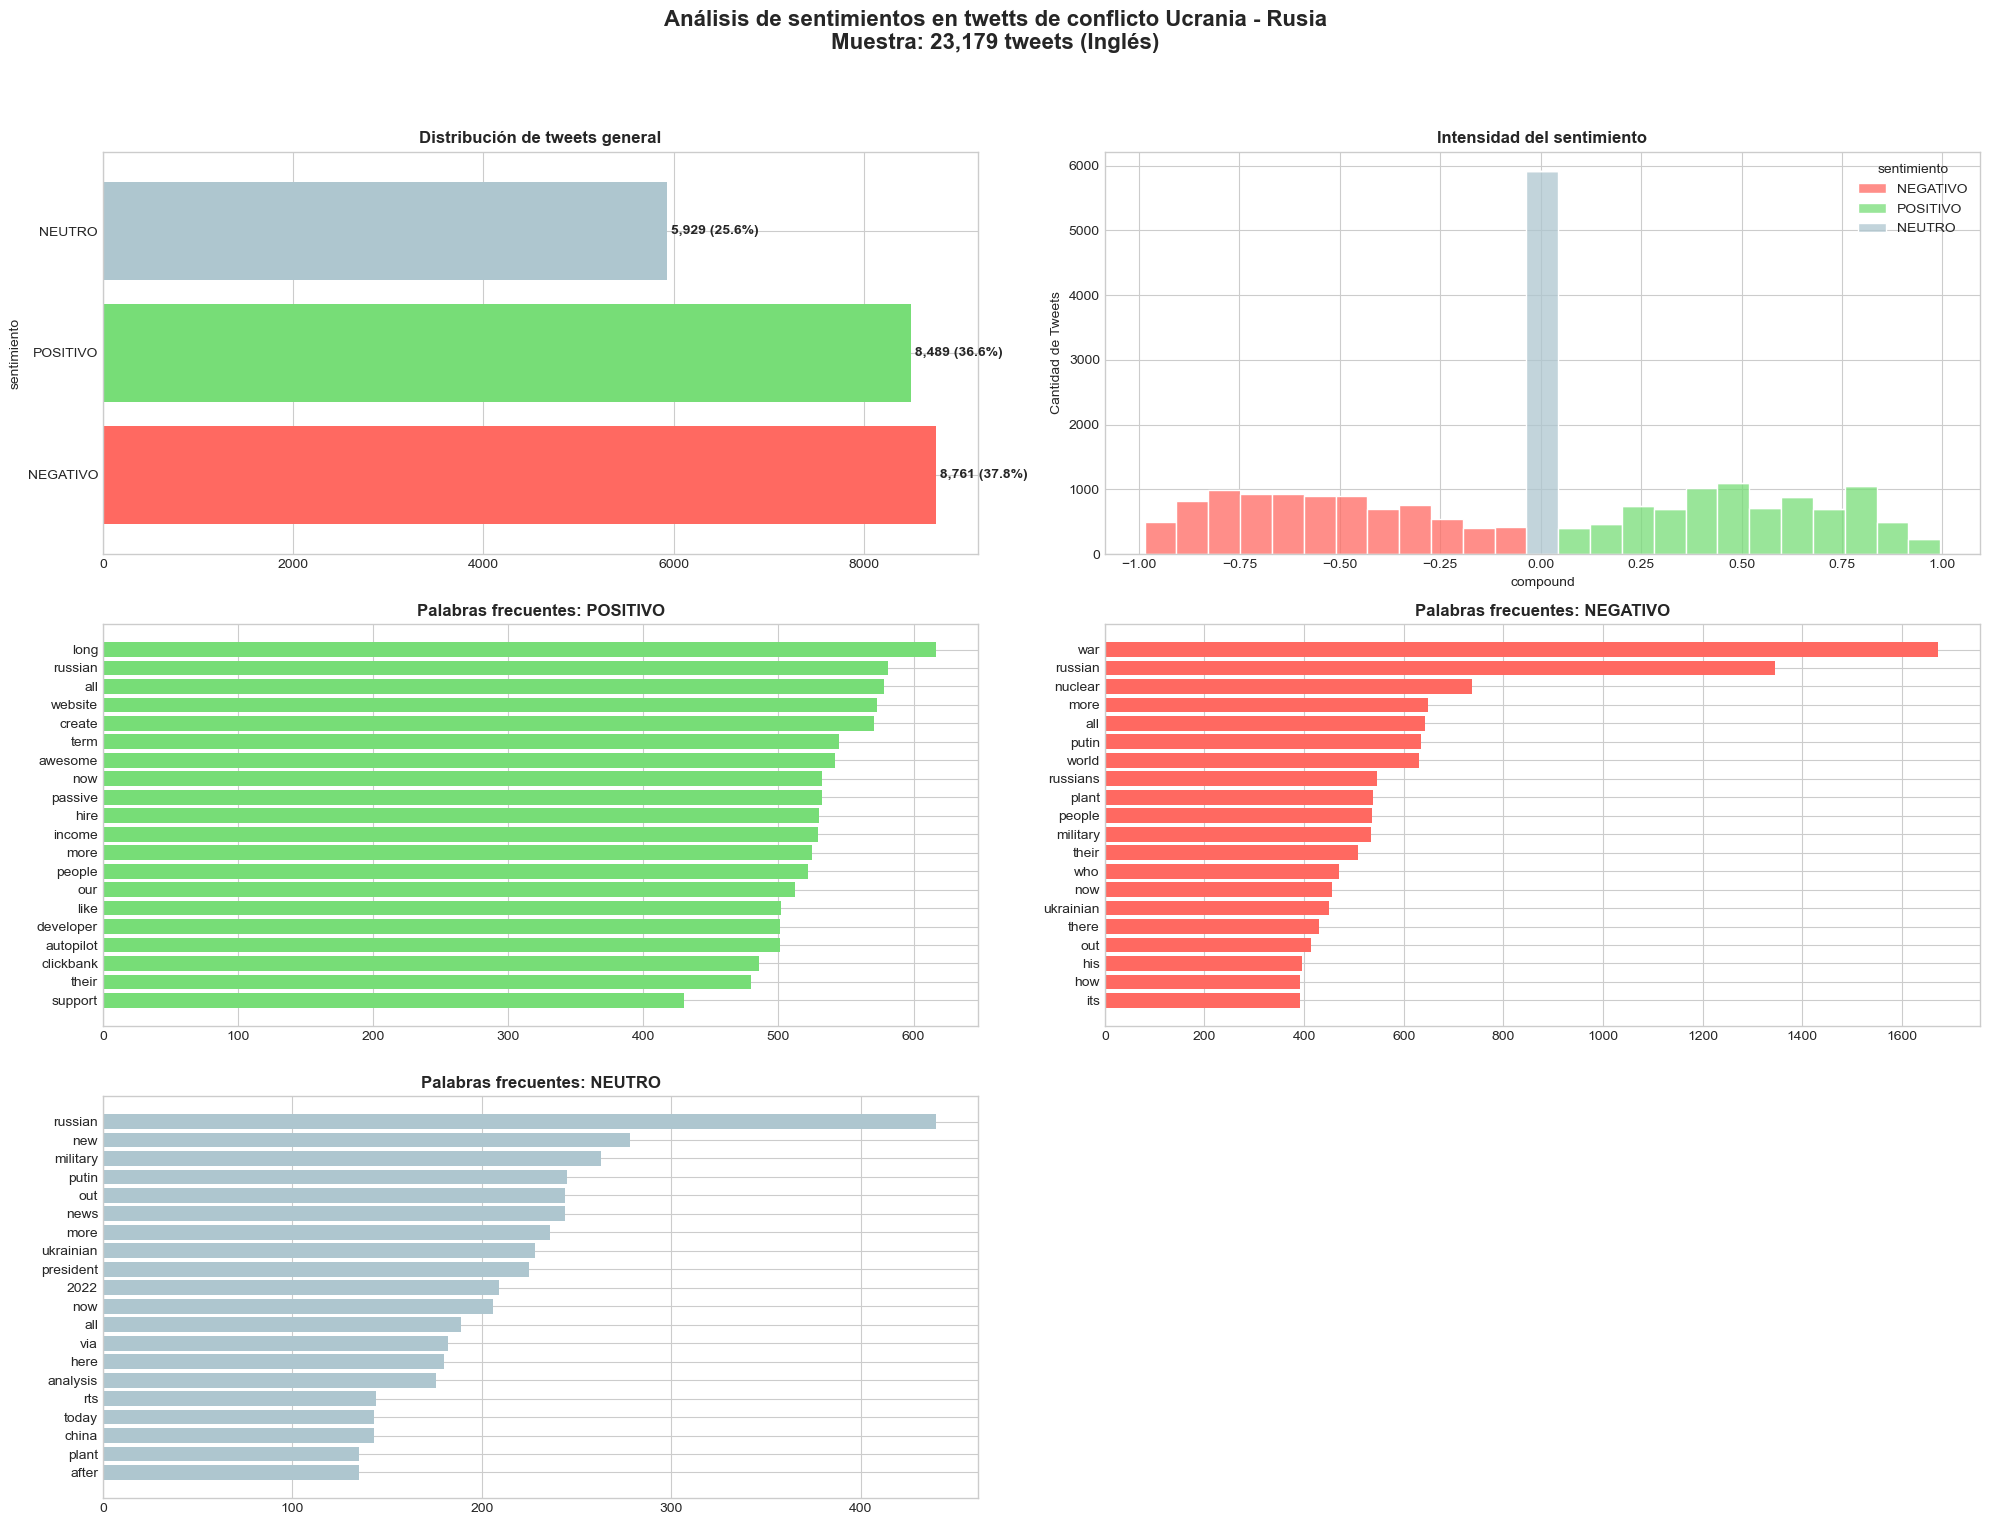

In [ ]:
# Gráficas
plt.style.use('seaborn-v0_8-whitegrid')
colores = {'POSITIVO': '#77DD77','NEGATIVO': '#FF6961','NEUTRO':   '#AEC6CF' }
excluidas = {'the', 'and', 'for', 'with', 'this', 'that', 'are', 'was', 'amp', 'were', 'from', 'have', 'has', 'but', 'not', 'you', 'they', 'ukraine', 'russia', 'will', 'can', 'what', 'your', 'about', 'co'}

fig, axs = plt.subplots(3, 2, figsize=(20, 16))
plt.suptitle(f'Análisis de sentimientos en twetts de conflicto Ucrania - Rusia\nMuestra: {len(df_ingles):,} tweets (Inglés)', fontsize=16, fontweight='bold', y=0.98)

# Gráfica de tipos de tweets
ax1 = axs[0, 0]
conteo = df_ingles['sentimiento'].value_counts()
conteo.plot(kind='barh', ax=ax1, color=[colores[k] for k in conteo.index], width=0.8)
# Porcentaje de tweets
for i, v in enumerate(conteo):
    ax1.text(v, i, f' {v:,} ({(v/len(df_ingles))*100:.1f}%)', va='center', fontweight='bold')
ax1.set_title('Distribución de tweets general', fontweight='bold')

# Histograma de sentimientos en tweets
ax2 = axs[0, 1]
sns.histplot(data=df_ingles, x='compound', hue='sentimiento', palette=colores, multiple='stack', bins=25, ax=ax2, edgecolor='white')
ax2.set_title('Intensidad del sentimiento', fontweight='bold')
ax2.set_ylabel('Cantidad de Tweets')

# Top de palabras por tipo de sentimiento
def top_palabras(texto_serie):
    #Unifica los tweets, los normaliza y busca patrones de palabras
    words = re.findall(r'\b\w{3,}\b', ' '.join(texto_serie).lower())

    # De las palabras obtenidas en la celda anterior las convierte en un diccionario y eliminamos las palabras "excluidas"
    return Counter([w for w in words if w not in excluidas]).most_common(20)

# Posiciones para los subplots de palabras
mapa_plots = [('POSITIVO', axs[1, 0]), ('NEGATIVO', axs[1, 1]), ('NEUTRO', axs[2, 0])]

axs[2, 1].axis('off')

for sent, ax in mapa_plots:
    # Filtramos las palabras en positivo, negativo y neutro
    subset = df_ingles[df_ingles['sentimiento'] == sent]
    if not subset.empty:
        words, counts = zip(*top_palabras(subset['filtrado_text']))
        ax.barh(words, counts, color=colores[sent])
        ax.invert_yaxis()
        ax.set_title(f'Palabras frecuentes: {sent}', fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Genera un archivo pdf para visualizar mejor los resultados
plt.savefig('analisis_sentimientos_twitter.pdf', bbox_inches='tight')
plt.show()

## Análisis de comentarios en un grupo de Facebook

In [ ]:
# Preprocesamiento de los datos del grupo de facebook
df = pd.read_csv('facebook_groups.csv')

if 'Content' not in df.columns:
    raise ValueError("La columna 'Content' no se encuentra en el CSV")

# Limpieza de los datos
def limpieza_datos(texto):
    if not isinstance(texto, str):
        return ""
    # Eliminamos URL´s
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)
    # Eliminamos las menciones a otros @usuarios
    texto = re.sub(r'@\w+', '', texto)
    # Eliminamos hashtags
    texto = re.sub(r'#\w+', '', texto)
    # Mantenemos solo palabras y puntuación enfática para mejorar el análisis de VADER
    texto = re.sub(r'[^\w\s!?.,:;()\'-]', ' ', texto)
    # Eliminar espacios múltiples
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

df['filtrado_Content'] = df['Content'].apply(limpieza_datos)
# Eliminamos filas que quedaron vacías después de la limpieza
df = df[df['filtrado_Content'] != ""]

In [ ]:
# Traducción
from deep_translator import GoogleTranslator

# Cargamos el traductor de google para traducir los comentarios del español a inglés para analizarlos adecuadamente con VADER
translator = GoogleTranslator(source='auto', target='en')

def traducir_texto(texto):
    try:
        if isinstance(texto, str) and texto.strip() and len(texto.strip()) > 2:
            # Intentar traducción
            traducido = translator.translate(texto.strip())
            # Verificar que la traducción no sea igual al original (indica fallo)
            if traducido.lower() != texto.lower() and len(traducido) > 0:
                return traducido
            else:
                return texto  # Si la traducción falló, devolver original
        return texto
    except Exception as e:
        return texto

# Aplicamos traducción
df['English_Content'] = df['filtrado_Content'].apply(traducir_texto)

In [ ]:
# Análisis de VADER

analyzer = SentimentIntensityAnalyzer()

def analizar_sentimiento(texto):
    # Calculamos los scores
    scores = analyzer.polarity_scores(str(texto))
    compound = scores['compound']

    # Clasificación
    if compound >= 0.05:
        return 'POSITIVO', compound
    elif compound <= -0.05:
        return 'NEGATIVO', compound
    else:
        return 'NEUTRO', compound

# Aplicamos VADER a la columna traducida
resultados = df['English_Content'].apply(lambda x: pd.Series(analizar_sentimiento(x)))
df[['sentimiento', 'compound']] = resultados

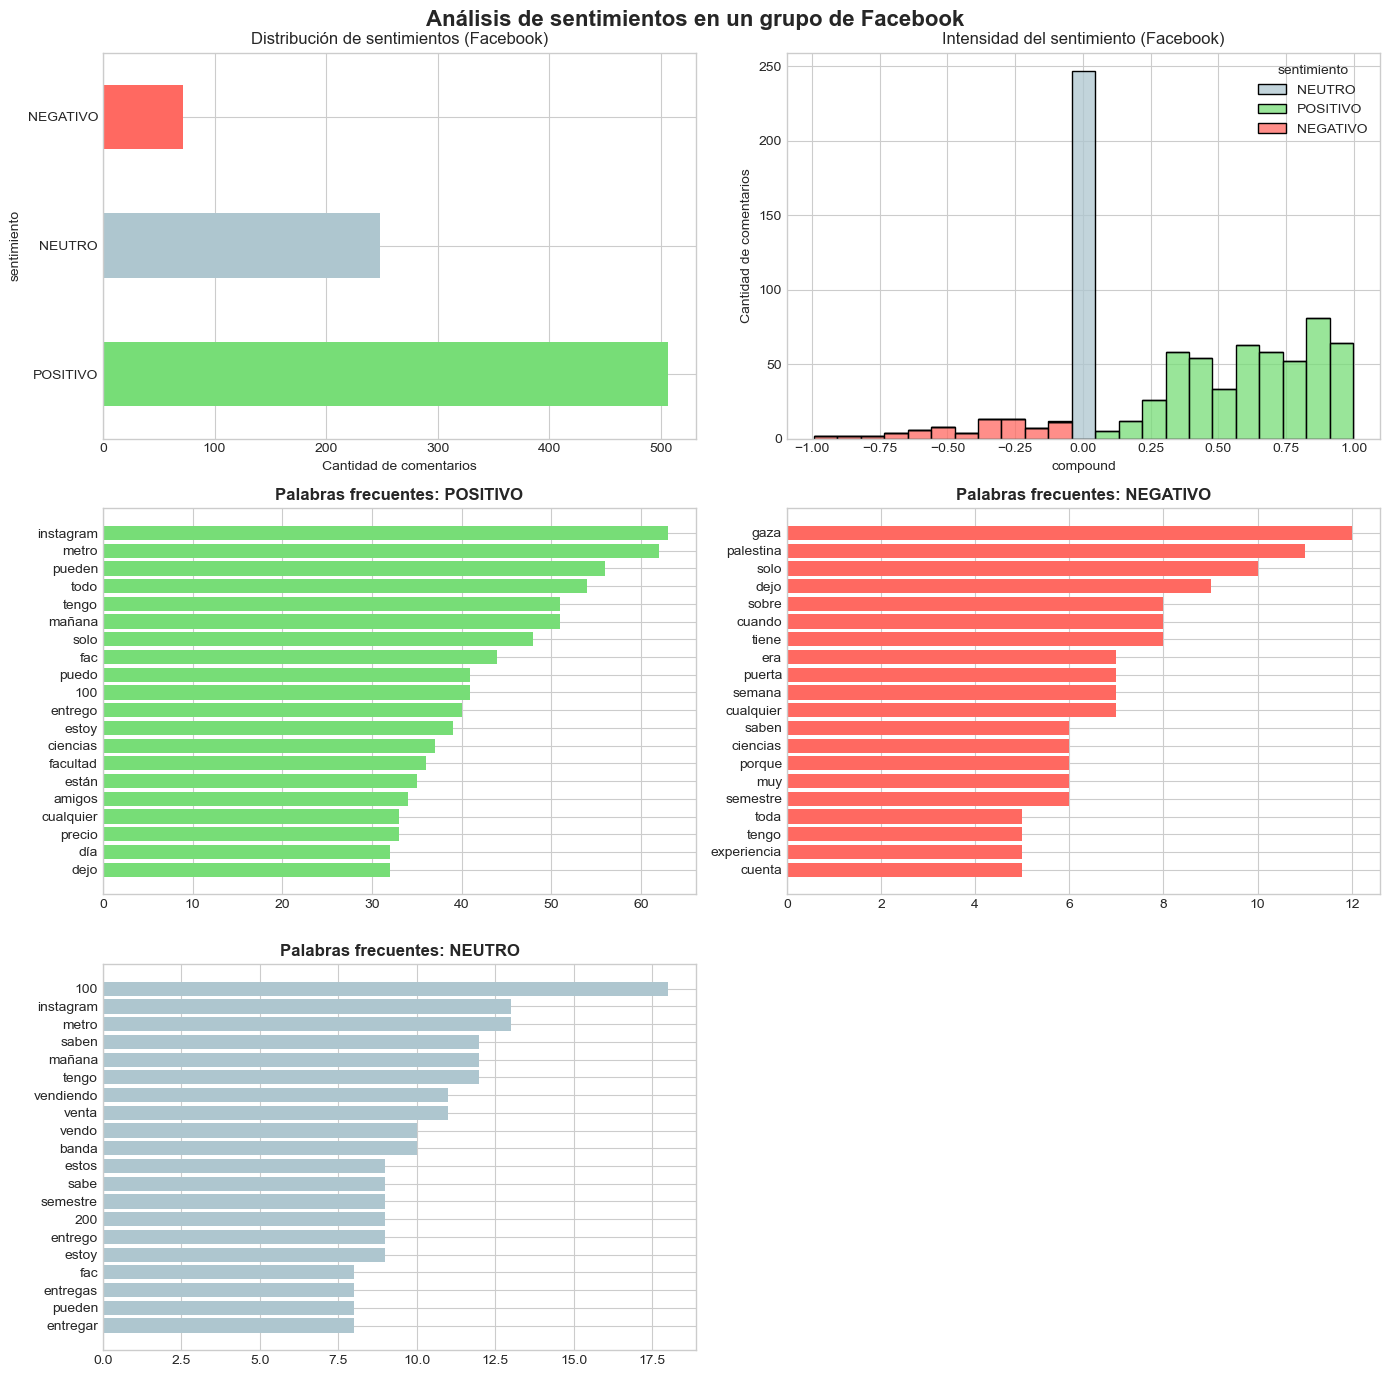

In [ ]:
# Gráficas
plt.style.use('seaborn-v0_8-whitegrid')
colores = {'POSITIVO': '#77DD77', 'NEGATIVO': '#FF6961', 'NEUTRO': '#AEC6CF'}

fig = plt.figure(figsize=(14, 14))
plt.suptitle(f'Análisis de sentimientos en un grupo de Facebook', fontsize=16, fontweight='bold', y=0.98)

# Gráfica 1. Conteo de sentimientos
ax1 = plt.subplot(3, 2, 1)  # 1 fila, 2 columnas, posición
conteo = df['sentimiento'].value_counts()
conteo.plot(kind='barh', ax=ax1, color=[colores.get(x, '#333') for x in conteo.index])
ax1.set_title('Distribución de sentimientos (Facebook)')
ax1.set_xlabel('Cantidad de comentarios')

# Gráfica 2. Histograma
ax2 = plt.subplot(3, 2, 2)  # 1 fila, 2 columnas, posición
sns.histplot(data=df, x='compound', hue='sentimiento', palette=colores, bins=23, ax=ax2, multiple='stack')
ax2.set_title('Intensidad del sentimiento (Facebook)')
ax2.set_ylabel('Cantidad de comentarios')


excluidas = {'los', 'del', 'https', 'www', 'hola', 'com','que', 'para', 'con', 'por', 'una', 'las', 'les', 'pero', 'alguien', 'más', 'son', 'este', 'como', 'sin', 'sus', 'igsh', 'esta', 'está', 'qué', 'ellas'}
# Top de palabras por tipo de sentimiento
def top_palabras(texto_serie):
    #Unifica los tweets, los normaliza y busca patrones de palabras
    words = re.findall(r'\b\w{3,}\b', ' '.join(texto_serie).lower())

    # De las palabras obtenidas en la celda anterior las convierte en un diccionario y eliminamos las palabras "excluidas"
    return Counter([w for w in words if w not in excluidas]).most_common(20)

# Posiciones para los subplots de palabras
mapa_plots = [('POSITIVO', plt.subplot(3, 2, 3)), ('NEGATIVO', plt.subplot(3, 2, 4)), ('NEUTRO', plt.subplot(3, 2, 5))]


for sent, ax in mapa_plots:
    # Filtramos las palabras en positivo, negativo y neutro
    subset = df[df['sentimiento'] == sent]
    if not subset.empty:
        words, counts = zip(*top_palabras(subset['Content']))
        ax.barh(words, counts, color=colores[sent])
        ax.invert_yaxis()
        ax.set_title(f'Palabras frecuentes: {sent}', fontweight='bold')

plt.tight_layout()

# Genera un archivo pdf para visualizar mejor los resultados
plt.savefig('analisis_sentimientos_facebook.pdf', bbox_inches='tight')
plt.show()